# Slide-seq_Hippocampus

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw = sodb.load_experiment('stickels2020highly','stickels2021highly_Slide-seqV2_Mouse_Hippocampus_Puck_200115_08')




load experiment[stickels2021highly_Slide-seqV2_Mouse_Hippocampus_Puck_200115_08] in dataset[stickels2020highly]


In [3]:
sc.pp.filter_cells(adata_raw, min_counts=10)
sc.pp.filter_genes(adata_raw, min_cells=10)

In [4]:
adata_raw.layers["counts"] = adata_raw.X.copy()
sc.pp.highly_variable_genes(adata_raw, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata_raw, inplace=True)
sc.pp.log1p(adata_raw)
sc.pp.pca(adata_raw)
sc.pp.neighbors(adata_raw)
sc.tl.umap(adata_raw)
sc.tl.leiden(adata_raw,resolution=2)

In [5]:
adata = adata_raw.copy()

In [6]:
# input parameters of MENDER
scale = 4

# main body of MENDER
msm = MENDER.MENDER_single(
    adata,
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='leiden'
)


estimated radius: 15.295751043999438


In [ ]:
adata.obs['ct']

In [7]:


# set the MENDER parameters


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=15, 

)
# construct the context representation
msm.run_representation(
    
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.5)



scale 0, median #cells per radius (r=15): 1.0
scale 1, median #cells per radius (r=15): 7.0
scale 2, median #cells per radius (r=15): 11.0
scale 3, median #cells per radius (r=15): 15.0


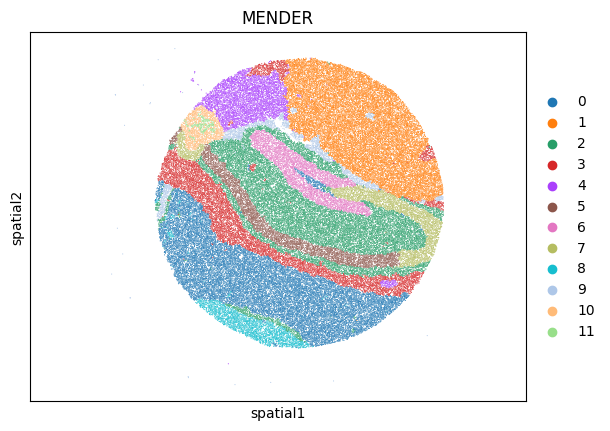

In [8]:
msm.output_cluster('MENDER')

In [9]:
msm.adata_MENDER.write_h5ad('dump/Slide-seq_Hippocampus.h5ad')